# PD de Validação de Modelos de Clusterização

## Importando bibliotecas

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
print('Versao do Numpy:', np.__version__)
print('Versao do Pandas:', pd.__version__)
print('Versao do Matplotlib:', plt.matplotlib.__version__)
print('Versao do Seaborn:', sns.__version__)

Versao do Numpy: 2.3.4
Versao do Pandas: 2.3.3
Versao do Matplotlib: 3.10.6
Versao do Seaborn: 0.13.2


## Importando Dataset

In [3]:
dados = pd.read_csv('H:/Machine learning/Clusterização de dados/Validação de modelos de clusterização/fruit_classification_dataset.csv')

dados.head()

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name
0,25.4,round,3089.2,137.1,green,sweet,watermelon
1,24.6,round,3283.9,163.8,green,sweet,watermelon
2,7.8,round,319.0,91.3,green,sweet,custard apple
3,20.0,oval,1607.0,85.7,orange,sweet,papaya
4,10.2,long,131.5,37.8,yellow,sweet,banana


**Foi escolhido este dataset para o PD para que eu possa trabalhar meu conehcimento com um novo grupo de dados, além disso, como também sou**
- formado em nutrição, trabalhar com alimentos une minhas duas áreas de atuação;
- podemos usar esse resultado de agrupamento para facilitar projeção de compras, de acordo com as similaridades entre elas, visando uma variação nas refeições e em projeção de custo.

In [4]:
dados.dtypes

size (cm)        float64
shape             object
weight (g)       float64
avg_price (₹)    float64
color             object
taste             object
fruit_name        object
dtype: object

In [5]:
dados.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   size (cm)      10000 non-null  float64
 1   shape          10000 non-null  object 
 2   weight (g)     10000 non-null  float64
 3   avg_price (₹)  10000 non-null  float64
 4   color          10000 non-null  object 
 5   taste          10000 non-null  object 
 6   fruit_name     10000 non-null  object 
dtypes: float64(3), object(4)
memory usage: 547.0+ KB


## Análise da faixa dinâmica de variáveis

Estatísticas Descritivas das Variáveis Numéricas:
          size (cm)    weight (g)  avg_price (₹)
count  10000.000000  10000.000000   10000.000000
mean       8.430600    455.457720      77.016720
std        6.396915    731.643087      38.946916
min        0.900000      4.500000       9.000000
25%        3.700000     45.800000      45.575000
50%        7.200000    168.800000      75.400000
75%       10.100000    365.275000     100.700000
max       27.500000   3299.800000     165.000000


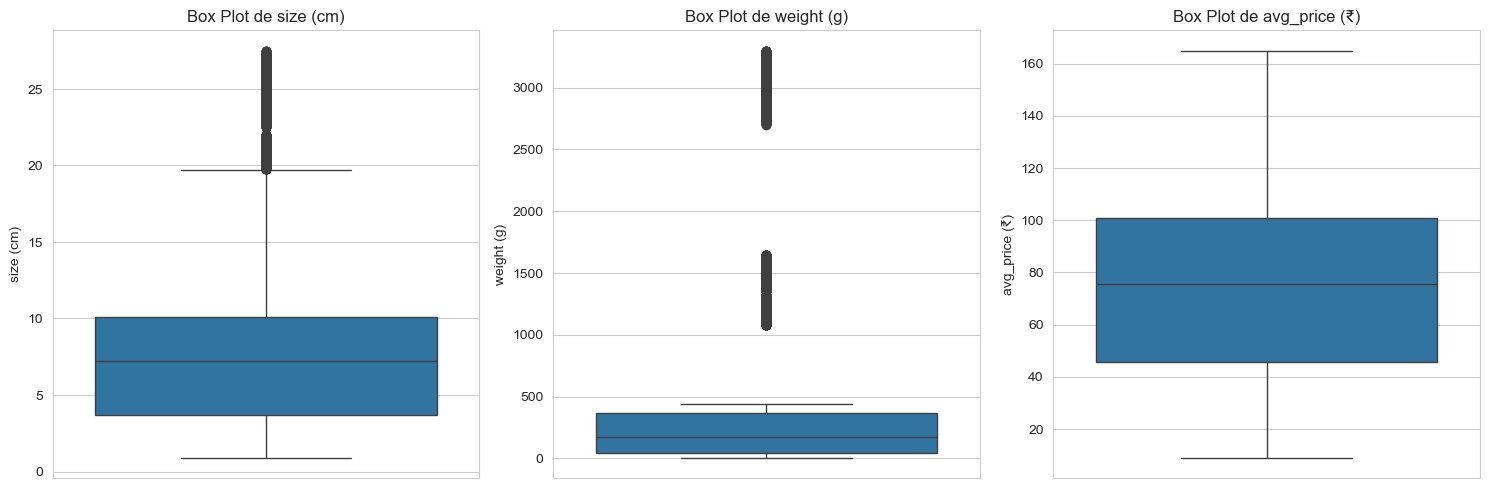

In [6]:
# Vamos selecionar as variáveis numéricas de interesse para clusterização
variaveis_numericas = ['size (cm)', 'weight (g)', 'avg_price (₹)']

# Agora mostrar as estatísticas descritivas (incluindo min/max)
print("Estatísticas Descritivas das Variáveis Numéricas:")
print(dados[variaveis_numericas].describe())

# E depois selecionar o estilo do gráfico
sns.set_style("whitegrid")

# Por último Criar box plots para visualizar a faixa dinâmica
plt.figure(figsize=(15, 5))

for i, col in enumerate(variaveis_numericas):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=dados[col])
    plt.title(f'Box Plot de {col}')
    plt.ylabel(col)
    
plt.tight_layout()
plt.show()

**Devido a alta variância de valores entre os dados de cada coluna, vamos padronizar os dados e evitar que o peso domine a clusterização** 

## Padronização dos dados

In [7]:
# Vamos usar o standard scaler para padronizar os dados
from sklearn.preprocessing import StandardScaler

# selecionar as variávies númericas a serem padronizadas
dados_numericos = dados[variaveis_numericas]

scaler = StandardScaler() #iniciando o padronizador

dados_padronizados_array = scaler.fit_transform(dados_numericos) #ajustando e transformando os dados

# Convertendo o array numpy de volta para um DataFrame do pandas
colunas_padronizadas = [f'{col}_padronizado' for col in variaveis_numericas]
dados_padronizados = pd.DataFrame(dados_padronizados_array, columns=colunas_padronizadas)

print("Dados Padronizados:")
print(dados_padronizados.describe().round(4))

Dados Padronizados:
       size (cm)_padronizado  weight (g)_padronizado  \
count             10000.0000              10000.0000   
mean                 -0.0000                  0.0000   
std                   1.0001                  1.0001   
min                  -1.1773                 -0.6164   
25%                  -0.7395                 -0.5599   
50%                  -0.1924                 -0.3918   
75%                   0.2610                 -0.1233   
max                   2.9812                  3.8878   

       avg_price (₹)_padronizado  
count                 10000.0000  
mean                      0.0000  
std                       1.0001  
min                      -1.7465  
25%                      -0.8073  
50%                      -0.0415  
75%                       0.6081  
max                       2.2592  


**Com os dados padronizados (média em torno de 0 e desvio padrão em torno de 1), vamos gerar novamente os boxplots**

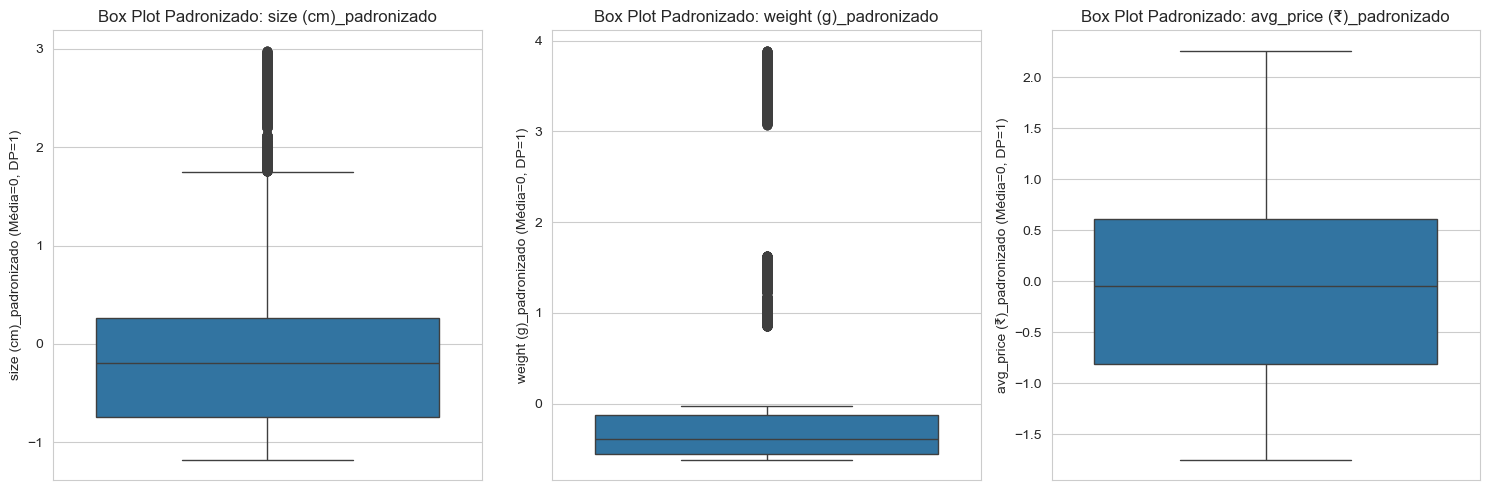

In [8]:
plt.figure(figsize=(15, 5))

for i, col in enumerate(colunas_padronizadas):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(y=dados_padronizados[col])
    plt.title(f'Box Plot Padronizado: {col}')
    plt.ylabel(f'{col} (Média=0, DP=1)')

plt.tight_layout()
plt.show()

## Calculando o índice de silhueta com K-Means

K=2, Índice de Silhueta: 0.5888
K=3, Índice de Silhueta: 0.4939
K=4, Índice de Silhueta: 0.5484
K=5, Índice de Silhueta: 0.5309
K=6, Índice de Silhueta: 0.5183
K=7, Índice de Silhueta: 0.5376
K=8, Índice de Silhueta: 0.5285
K=9, Índice de Silhueta: 0.4984
K=10, Índice de Silhueta: 0.5259


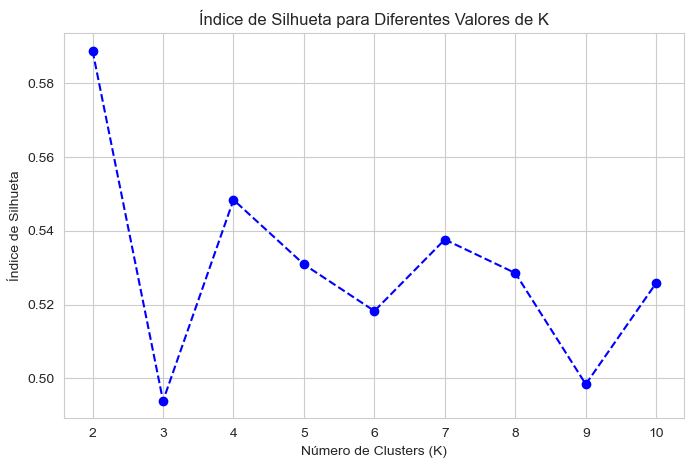

O melhor número de clusters (K) é: 2


In [9]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

#calculando o índice de silhueta para valores de K de 2 a 10
silhueta_scores = []    
k_range = range(2, 11) #lembrando que o K deve ser no mínimo 2

for k in k_range:
    kmeans = KMeans(n_clusters = k, random_state =  42, n_init = 'auto') #n_init='auto' para evitar warnings
    labels = kmeans.fit_predict(dados_padronizados) #ajustando e prevendo os clusters
    #calculando o índice de silhueta
    score = silhouette_score(dados_padronizados, labels) #calculando o score
    silhueta_scores.append(score) #armazenando o score
    print(f'K={k}, Índice de Silhueta: {score:.4f}') #exibindo o resultado  

# Plotando o índice de silhueta para diferentes valores de K
plt.figure(figsize=(8, 5))
plt.plot(k_range, silhueta_scores, marker='o', linestyle='--', color = 'blue')
plt.title('Índice de Silhueta para Diferentes Valores de K')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('Índice de Silhueta')
plt.xticks(k_range) #definindo os ticks do eixo x
plt.grid(True) #adicionando grade ao gráfico
plt.show()

# Escolhendo o K com o maior índice de silhueta
melhor_k = k_range[np.argmax(silhueta_scores)]
print(f'O melhor número de clusters (K) é: {melhor_k}')

In [10]:
# Aplicando o Kmeans com o melhor K encontrado
dados1 = dados.copy()  # Criar uma cópia do DataFrame original para adicionar os clusters
kmeans_final = KMeans(n_clusters=melhor_k, random_state=42, n_init='auto')
dados1['Cluster'] = kmeans_final.fit_predict(dados_padronizados)

dados1.head(16)

,size (cm),shape,weight (g),avg_price (₹),color,taste,fruit_name,Cluster
0,25.4,round,3089.2,137.1,green,sweet,watermelon,1
1,24.6,round,3283.9,163.8,green,sweet,watermelon,1
2,7.8,round,319.0,91.3,green,sweet,custard apple,0
3,20.0,oval,1607.0,85.7,orange,sweet,papaya,1
4,10.2,long,131.5,37.8,yellow,sweet,banana,0
5,19.4,oval,1404.1,86.0,orange,sweet,papaya,1
6,6.3,round,262.3,125.0,red,sweet,pomegranate,0
7,0.9,round,5.4,9.4,purple,sweet,grape,0
8,4.0,round,46.4,66.9,purple,tangy,plum,0
9,7.6,round,274.7,93.0,green,sweet,custard apple,0


In [11]:
# --- CÓDIGO PARA ANÁLISE DE VARIAÇÃO ---
print("Variação (Desvio Padrão) das Variáveis por Cluster (K=2):")

# 1. Calcular o desvio padrão das colunas numéricas originais, agrupado por 'Cluster_2'
variacao_clusters = dados1.groupby('Cluster')[variaveis_numericas].std().reset_index()

# 2. Renomear colunas para maior clareza
variacao_clusters.columns = ['Cluster', 'DP Tamanho (cm)', 'DP Peso (g)', 'DP Preço (₹)']

# 3. Exibir o resultado
print(variacao_clusters.round(2))

Variação (Desvio Padrão) das Variáveis por Cluster (K=2):
   Cluster  DP Tamanho (cm)  DP Peso (g)  DP Preço (₹)
0        0             2.96       119.28         38.22
1        1             3.79       755.47         27.64


**A nossa padronização de 2 clusters resultou em dois grupos:**
- Grupo 0: frutas pequenas e leves como uva, maçã, mirtillo
- Grupo 1: frutas grandes e pesadas como coco, melancia e mamão papaya
- A variação de preço não importou muito nesta separação

## Calculando o índice de silhueta com DBScan

In [12]:
from sklearn.cluster import DBSCAN

# CONFIGURAÇÃO DO DBSCAN 
min_samples = 6 # (2 * nº de dimensões)
eps_testes = np.arange(0.1, 1.5, 0.1) # Testando epsilon de 0.1 a 1.4

dbscan_scores = []
n_clusters_list = []

print(f"Testando DBSCAN com min_samples={min_samples}:")

for eps in eps_testes:
    dbscan = DBSCAN(eps=eps, min_samples=min_samples)
    labels = dbscan.fit_predict(dados_padronizados)
    
    # Contar o número de clusters (excluindo ruído, que é rotulado como -1)
    n_clusters = len(np.unique(labels)) - (1 if -1 in labels else 0)
    
    if n_clusters > 1:  # O índice de silhueta só é definido para 2 ou mais clusters
        #filtrando os dados para excluir o ruído (outliers)
        dados_filtrados = dados_padronizados[labels != -1]
        labels_filtrados = labels[labels != -1]

        score = silhouette_score(dados_filtrados, labels_filtrados)
        dbscan_scores.append(score)
        n_clusters_list.append(n_clusters)
        print(f"  Epsilon={eps:.1f}: Clusters={n_clusters}, Silhueta={score:.4f}")
    else:
        dbscan_scores.append(0)  # Atribuir zero quando não há clusters suficientes
        n_clusters_list.append(n_clusters)
        print(f"  Epsilon={eps:.1f}: Clusters={n_clusters} (Não calculado)")

Testando DBSCAN com min_samples=6:
  Epsilon=0.1: Clusters=30, Silhueta=0.5579
  Epsilon=0.2: Clusters=8, Silhueta=0.4473
  Epsilon=0.3: Clusters=5, Silhueta=0.2515
  Epsilon=0.4: Clusters=4, Silhueta=0.3310
  Epsilon=0.5: Clusters=3, Silhueta=0.5566
  Epsilon=0.6: Clusters=3, Silhueta=0.5566
  Epsilon=0.7: Clusters=3, Silhueta=0.5566
  Epsilon=0.8: Clusters=3, Silhueta=0.5566
  Epsilon=0.9: Clusters=3, Silhueta=0.5566
  Epsilon=1.0: Clusters=3, Silhueta=0.5566
  Epsilon=1.1: Clusters=3, Silhueta=0.5566
  Epsilon=1.2: Clusters=3, Silhueta=0.5566
  Epsilon=1.3: Clusters=2, Silhueta=0.6453
  Epsilon=1.4: Clusters=2, Silhueta=0.6453


<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:14: SyntaxWarning: invalid escape sequence '\e'
C:\Users\luizd\AppData\Local\Temp\ipykernel_19252\717243.py:7: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Epsilon ($\epsilon$)')
C:\Users\luizd\AppData\Local\Temp\ipykernel_19252\717243.py:14: SyntaxWarning: invalid escape sequence '\e'
  plt.xlabel('Epsilon ($\epsilon$)')


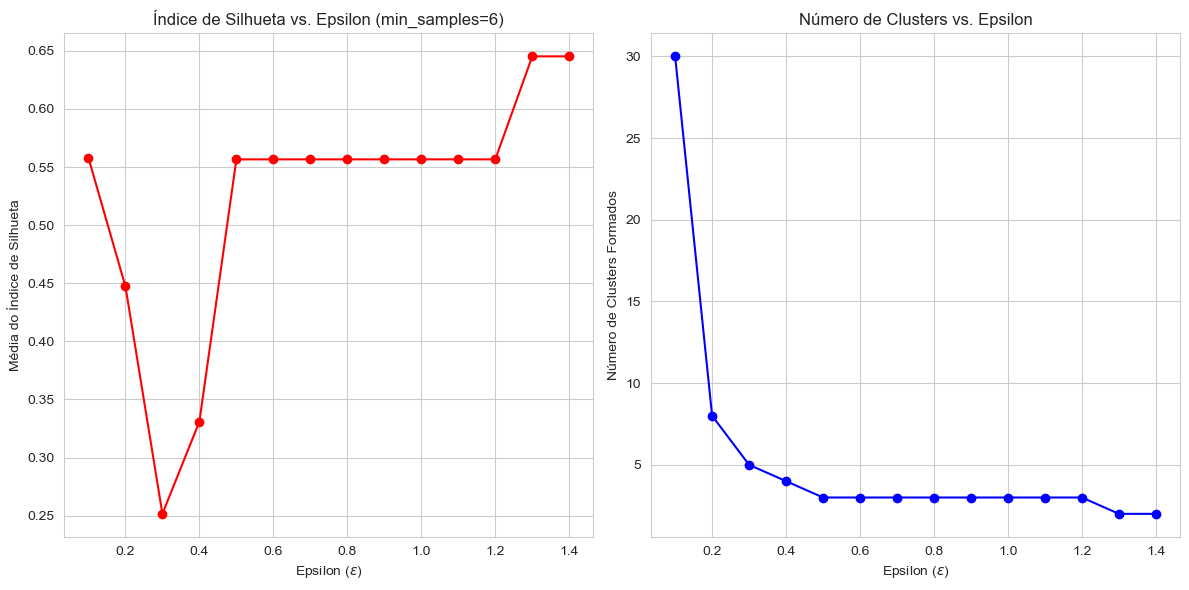

In [13]:
# --- VISUALIZAÇÃO DOS RESULTADOS ---
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(eps_testes, dbscan_scores, marker='o', linestyle='-', color='red')
plt.title(f'Índice de Silhueta vs. Epsilon (min_samples={min_samples})')
plt.xlabel('Epsilon ($\epsilon$)')
plt.ylabel('Média do Índice de Silhueta')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(eps_testes, n_clusters_list, marker='o', linestyle='-', color='blue')
plt.title('Número de Clusters vs. Epsilon')
plt.xlabel('Epsilon ($\epsilon$)')
plt.ylabel('Número de Clusters Formados')
plt.grid(True)

plt.tight_layout()
plt.show()

**Fazendo a análise dos dados obtidos:**
- Percebe-se que ao chegar no número 2 de clusters, obtemos a melhor média de índice de silhueta (aproximadamente 0,65);
- O pico inicial mostra que 30 clusters ficariam bem separados, entretanto, o resultado obtido com 2 ainda é bem melhor (0,6453 vs 0,5888)

**Uma análise sobre o coeficiente de silhueta e o DBSCAN**
- Apesar do coeficiente de silhueta ser uma métrica muito utilizada para medir coesão e separação de clusters, ele possui limitações quando utilizado em modelos baseados em densidade (caso do DBSCAN);
- A silhueta inicialmente foi pensada para se comportar melhor com estruturas de cluster aproximadamente convexas e bem separadas (como cluesters do k-means);
- A capacidade do DBSCAN de identificar clusters de formas complexas e não convexas, associadas a presença intrínseca de ruídos pode distorcer o coeficiente de silhueta, frequentemente resultado em valores mais baixos, mesmo em um agrupamento visualmente coerente;
- Desse modo, o índice de davies-bouldin (DBI) acaba sendo uma métrica mais relevante para uma comparação direta entre k-means e DBSCAN, onde iremos calcular mais a frente neste notebook

In [14]:
# Aplicar DBSCAN com parâmetros ideais obtidos acima
eps_ideal = 1.3
min_samples_ideal = 6
dbscan = DBSCAN(eps=eps_ideal, min_samples=min_samples_ideal)
dados['Cluster_DBSCAN'] = dbscan.fit_predict(dados_padronizados)

# O DBSCAN atribui o rótulo -1 aos outliers. Vamos incluí-los na contagem
n_outliers = (dados['Cluster_DBSCAN'] == -1).sum()
n_clusters = len(dados['Cluster_DBSCAN'].unique()) - (1 if -1 in dados['Cluster_DBSCAN'].unique() else 0)

print(f"Configuração do DBSCAN")
print(f"Clusters Formados: {n_clusters}")
print(f"Outliers (-1): {n_outliers} (representando {n_outliers/len(dados)*100:.2f}% dos dados)")
print("------------------------------")

# Análise Descritiva: Média dos Clusters
analise_media = dados[dados['Cluster_DBSCAN'] != -1].groupby('Cluster_DBSCAN')[variaveis_numericas].mean().reset_index()
analise_media.columns = ['Cluster', 'Média Tamanho (cm)', 'Média Peso (g)', 'Média Preço (₹)']

print("\n Características Médias dos Clusters DBSCAN (sem Outliers):")
print(analise_media.round(2))

# Análise de Variação: Desvio Padrão dos Clusters
analise_std = dados[dados['Cluster_DBSCAN'] != -1].groupby('Cluster_DBSCAN')[variaveis_numericas].std().reset_index()
analise_std.columns = ['Cluster', 'DP Tamanho (cm)', 'DP Peso (g)', 'DP Preço (₹)']

print("\n Variação (DP) dos Clusters DBSCAN (sem Outliers):")
print(analise_std.round(2))

Configuração do DBSCAN
Clusters Formados: 2
Outliers (-1): 0 (representando 0.00% dos dados)
------------------------------

 Características Médias dos Clusters DBSCAN (sem Outliers):
   Cluster  Média Tamanho (cm)  Média Peso (g)  Média Preço (₹)
0        0               24.95         3013.70           150.63
1        1                7.57          321.38            73.16

 Variação (DP) dos Clusters DBSCAN (sem Outliers):
   Cluster  DP Tamanho (cm)  DP Peso (g)  DP Preço (₹)
0        0             1.45       173.20          8.28
1        1             5.28       448.08         35.97


**Analisando os dados acima, podemos perceber:**
- Todas as frutas conseguiram ser incluídas em algum dos dois clusters, ou seja, nenhuma fruta foi considerada outliers;
- O cluster 0 agrupou as frutas grandes, pesadas e caras;
- O cluster 1 agrupou as frutas leves, pequenas e baratas.

## Escolhendo outras duas medidas de validação para realizar a comparação com os resultados encontrados

Resultados da Validação:
  K-Means (DBI): 0.6832
  DBSCAN (DBI): 0.3199


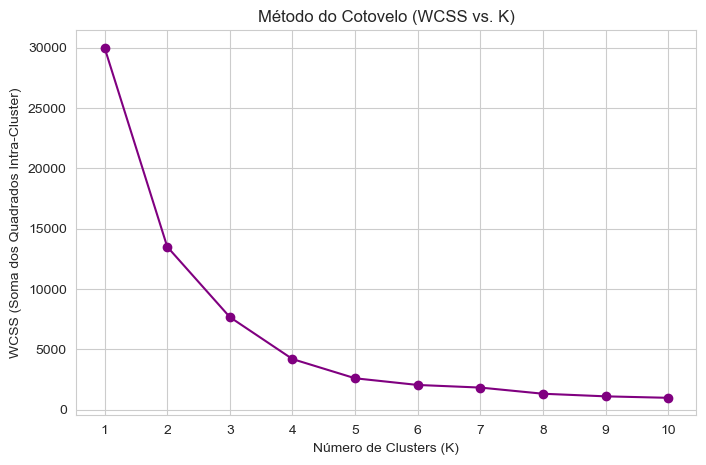

In [15]:
from sklearn.metrics import davies_bouldin_score
labels_true = dados['fruit_name'] # Rótulos de Verdade

#KMeans K = 2
labels_kmeans = kmeans_final.fit_predict(dados_padronizados)

#DBSCAN epsilon = 1.3, min_samples = 6
labels_dbscan = dbscan.fit_predict(dados_padronizados)

# Métricas 
resultados = {}

# 1 - DBI - Avaliando separação
# para o K-Means
resultados['K-Means (DBI)'] = davies_bouldin_score(dados_padronizados, labels_kmeans)

# para o DBSCAN
resultados['DBSCAN (DBI)'] = davies_bouldin_score(dados_padronizados, labels_dbscan)

# 2 - WCSS - método do cotovelo 
# para o K-Means
wcss_scores = []
k_range = range(1, 11)

for k in k_range:
    kmeans_wcss = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans_wcss.fit(dados_padronizados)
    wcss_scores.append(kmeans_wcss.inertia_)

# Resultados
print("Resultados da Validação:")
for metrica, valor in resultados.items():
    print(f"  {metrica}: {valor:.4f}")

# Exibir WCSS (Cotovelo) para análise visual
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss_scores, marker='o', linestyle='-', color='purple')
plt.title('Método do Cotovelo (WCSS vs. K)')
plt.xlabel('Número de Clusters (K)')
plt.ylabel('WCSS (Soma dos Quadrados Intra-Cluster)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

**Fazendo a análise dos dados obtidos, podemos responder que:**
- O DBI indica que o DBScan separou os clusters de maneira mais compacta, separando as frutas de uma melhor forma (indicado pelo DBI de menor valor);
- Foi utilizado métricas internas para avaliação, pois os nomes das frutas não geram correlação com seus tamanhos e valores, não sendo possível usar de um bom modo métricas como ARI;
- O método do cotovelo indica também que o melhor número de clusters seriam 2, conforme obtido nas análises anteriores (maior queda de WCSS, depois começando um achatamento entre as quedas)

| Métrica  | K-Means (k=2) | DBSCAN (K=2) | Interpretação |
| -------- | --------------| -------------|---------------|
| Coeficiente de Silhueta (Silhouette Score)      | 0.5888     | 0.6453     | Mede a coesão (quão perto estão do seu cluster) e separação (quão longe estão dos outros clusters). Maior é melhor. |
| BÍndice Davies-Bouldin (DBI)        |   0.6832   | 0.3199  | Mede a relação entre a dispersão intra-cluster e a separação inter-cluster. Menor é melhor. |


## Medidas de similariade

**Passo a passo para agrupar 10 séries temporais distintas em 3 grupos, de acordo com critério de similiaridade, baseado no valor máximo de correlação cruzada entre elas:**

- 1º passo: Importar os dados, garantindo que todas possuam a mesma frequência de amostragem e que estejam sincronizadas (índices de tempo correspondam);
- 2º passo: Pré-processamento dos dados, podemos usar aqui a normalização ou a padronização - Evitar que as diferenças de magnitude afetem a medidada de similaridade;
- 3º passo: Fazer o cálculo de similiaridade usando uma matriz de distância:
    * Calcular a correlação cruzada entre os pares de séries temporais;
    * Determinar a similiaridade, encontrando o valor máximo absoluto da correlação cruzada de cada par (uma medida robusta de similaridade de forma);
    * Construir a matriz de distância fazendo a transformação da similiaridade em distância (distância = 1 - similaridade) - Resultar em matriz quadrada onde cada entrada representa a dissimilaridade entre um par de séries;
- 4º passo: aplicar um algoritmo de clusterização: Entrada é a matriz contruída no passo 3, o número de clusters é 3, pelo tipo do problema, minha sugestão é de usar um algoritmo de agrupamento hierárquico para tal situação:
    * Ela aceita a entrada direta de uma matriz de distância customizada, conforme construída no passo anterior;
    * Defino a natureza visual do dendograma, facilitando a análise da separação entre as séries temporais e a justificativa do porque de 3 clusters serem escolhidos, se necessário;
- 5º passo: Fazer uma análise dos resultados obtidos, podendo ser utilizado o coeficiente de silhueta para essa análise.

**Caso de uso sugerido para a solução projetada:**
- Como a base da solução citada é a similiaridade, mesmo se estiver defasado com o tempo, podemos usar esse tipo de agrupamento para ativos financeiros como ações ou fundos imobiliários:
    * Como o mercado financeiro é interligado, o movimento de um ativo pode influenciar em outro, a correlação cruzada identifica a relação liderança-seguimento, conehcida como causalidade de granger;
    * Podemos montar uma estratégia de trading, onde se um ativo X está fortemente ligado a um ativo Y com uma defasagem de 3 dias, se X se movimenta hoje, podemos prever como Y vai se movimentar dentro de 3 dias;
    * Para uma boa diversificação financeira, ativos fortemente ligados deveriam é ruim para essa diversificação. Um bom gestor, procuraria ativos de diferentes clusters para montar sua carteira;
    * Ainda poderia usar uma estratégia de pair trading, onde a similaridade em defasagem auxilia a identificar pares para estratégias de trading onde se aposta na convergência (ou divergência) de ativos que costumam se mover de forma similar.

**Segunda estratégia para determinar similaridade:**
- Podemos utilizar a Distância Euclidiana Dinâmica no Tempo: mede a similaridade entre duas séries temporais, encontrando o alinhamento ótimo que minimizar a soma das distâncias entre os pontos correspondentes;
- Ele permite que um ponto em uma série seja mapeado para vários pontos na outra série;
- A determinação da similaridade se daria por uma matriz de distâncias onde cada elemento (i,j) representa a distância entre o ponto i da série X até o ponto j da série Y:
    * O caminho ótimo é obtido por um algoritmo de programação dinâmica encontra o "caminho de dobra" (warping path) através desta matriz que resulta no custo de alinhamento acumulado mínimo;
    * Esse custo mínimo acumulado é a distância DTW entre 2 séries, quanto menor ela for, maior a similaridade de forma.

- Vantagens:
    * Insensível a distorções de tempo: robusta a séries com mesmo padrão mas que ocorrem em velocidades diferentes;
    * Medida direta de distância: O resultado da DTW é uma métrica de distância pronta para ser usada no agrupamento hierárquico (ou no k-medóides)